# Predicting cancer cachexia from urinary NMR metabolites

Binary classification of cachexic vs control subjects from urinary ¹H-NMR metabolite profiles, benchmarking five classifiers by cross-validated ROC-AUC.

## Data preparation and cleaning

Load the urinary metabolite data, standardise the class label, restrict to the 30 metabolites most associated with muscle wasting, and log10-transform concentrations.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [4]:
# Read data into dataframe
df = pd.read_excel('data/metabolites.xlsx', sheet_name = 'Sheet1')

# Check structure
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Types:', df.dtypes)
print(df.head(5))
print(df.describe(include = 'all'))

# Check for missing values
missing_vals = df.isna().sum().sort_values()
print('Missing values:', missing_vals[missing_vals > 0])

Shape: (75, 66)
Columns: ['ID', 'Label', 'Label.1', '1,6-Anhydro-beta-D-glucose', '1-Methylnicotinamide', '2-Aminobutyrate', '2-Hydroxyisobutyrate', '2-Oxoglutarate', '3-Aminoisobutyrate', '3-Hydroxybutyrate', '3-Hydroxyisovalerate', '3-Indoxylsulfate', '4-Hydroxyphenylacetate', 'Acetate', 'Acetone', 'Adipate', 'Alanine', 'Asparagine', 'Betaine', 'Carnitine', 'Citrate', 'Creatine', 'Creatinine', 'Dimethylamine', 'Ethanolamine', 'Formate', 'Fucose', 'Fumarate', 'Glucose', 'Glutamine', 'Glycine', 'Glycolate', 'Guanidoacetate', 'Hippurate', 'Histidine', 'Hypoxanthine', 'Isoleucine', 'Lactate', 'Leucine', 'Lysine', 'Methylamine', 'Methylguanidine', 'N,N-Dimethylglycine', 'O-Acetylcarnitine', 'Pantothenate', 'Pyroglutamate', 'Pyruvate', 'Quinolinate', 'Serine', 'Succinate', 'Sucrose', 'Tartrate', 'Taurine', 'Threonine', 'Trigonelline', 'Trimethylamine N-oxide', 'Tryptophan', 'Tyrosine', 'Uracil', 'Valine', 'Xylose', 'cis-Aconitate', 'myo-Inositol', 'trans-Aconitate', 'pi-Methylhistidine', '

In [5]:
# Rename 'Label.1' column to 'Class'
df.rename(columns = {'Label.1' : 'Class'}, inplace = True)

# Make sure the values in class are numeric
df['Class'] = pd.to_numeric(df['Class'])

# Make sure all labels are either 'control' or 'cachexic'
wrong_labels = df[((df['Label'] != 'control') & (df['Label'] != 'cachexic'))]
print('Wrong labels:', wrong_labels)

# Recategorise class values to 0 for control, 1 for cachexic
df.loc[(df['Label'] == 'cachexic'), 'Class'] = 1
df.loc[(df['Label'] == 'control'), 'Class'] = 0

# Check recategorisation
mismatches = df[
    ((df['Label'] == 'control') & (df['Class'] != 0)) |
    ((df['Label'] == 'cachexic') & (df['Class'] != 1))
     ]

print('Mismatches:', mismatches)

Wrong labels: Empty DataFrame
Columns: [ID, Label, Class, 1,6-Anhydro-beta-D-glucose, 1-Methylnicotinamide, 2-Aminobutyrate, 2-Hydroxyisobutyrate, 2-Oxoglutarate, 3-Aminoisobutyrate, 3-Hydroxybutyrate, 3-Hydroxyisovalerate, 3-Indoxylsulfate, 4-Hydroxyphenylacetate, Acetate, Acetone, Adipate, Alanine, Asparagine, Betaine, Carnitine, Citrate, Creatine, Creatinine, Dimethylamine, Ethanolamine, Formate, Fucose, Fumarate, Glucose, Glutamine, Glycine, Glycolate, Guanidoacetate, Hippurate, Histidine, Hypoxanthine, Isoleucine, Lactate, Leucine, Lysine, Methylamine, Methylguanidine, N,N-Dimethylglycine, O-Acetylcarnitine, Pantothenate, Pyroglutamate, Pyruvate, Quinolinate, Serine, Succinate, Sucrose, Tartrate, Taurine, Threonine, Trigonelline, Trimethylamine N-oxide, Tryptophan, Tyrosine, Uracil, Valine, Xylose, cis-Aconitate, myo-Inositol, trans-Aconitate, pi-Methylhistidine, tau-Methylhistidine]
Index: []

[0 rows x 66 columns]
Mismatches: Empty DataFrame
Columns: [ID, Label, Class, 1,6-Anhyd

In [6]:
top30_metabolites = ['Adipate',
                      'Glucose',
                      'Quinolinate',
                      'myo-Inositol',
                      'Valine',
                      'Succinate',
                      'Betaine',
                      'Leucine',
                      'N,N-Dimethylglycine',
                      '3-Hydroxyisovalerate',
                      'Creatine',
                      'Acetate',
                      'Alanine',
                      'Pyroglutamate',
                      '3-Hydroxybutyrate',
                      'Glutamine',
                      'cis-Aconitate',
                      'Methylamine',
                      'Tryptophan',
                      'Dimethylamine',
                      'Xylose',
                      'Creatinine',
                      'Formate',
                      'Tyrosine',
                      'trans-Aconitate',
                      'Lactate',
                      'Sucrose',
                      '2-Hydroxyisobutyrate',
                      'Serine',
                      'Threonine'
                     ]

# Check metabolites match df columns
missing_cols = [col for col in top30_metabolites if col not in df.columns]
print('Missing columns:', missing_cols)

# Missing columns: ['Myo-inositol', 'N,N-dimethylglycine', 'Cis-aconitate', 'Trans-aconitate']
# Changed names from paper to match df

Missing columns: []


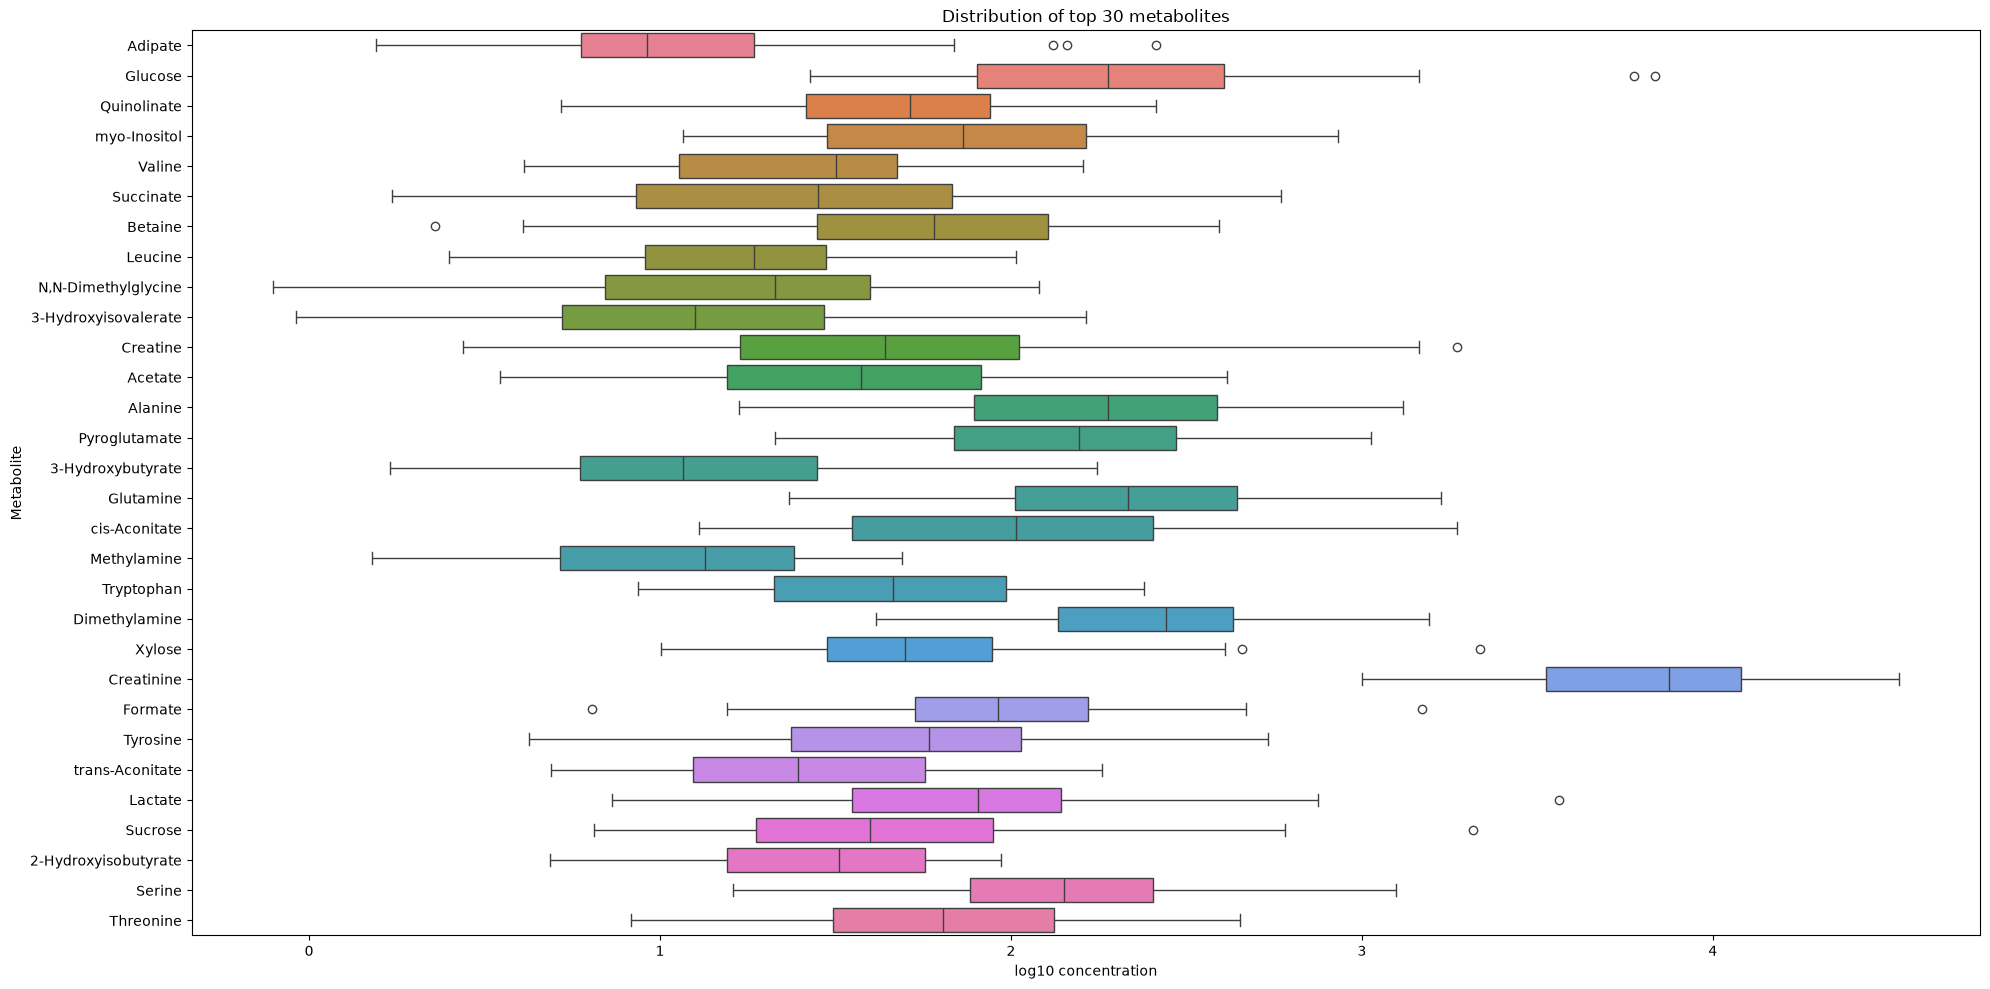

In [7]:
# Create a df with metabolite concentrations measured in log10
df_log10 = df.copy()
for met in top30_metabolites:
    df_log10[met] = np.log10(df[met] + 1e-6) # Addition of small value to prevent log of 0

# Boxplots of metabolite concentrations
plt.figure(figsize = (20, 10))
sns.boxplot(data = df_log10[top30_metabolites], orient = 'h') # Addition of small value to prevent log of 0
plt.title('Distribution of top 30 metabolites')
plt.ylabel('Metabolite')
plt.xlabel('log10 concentration')
plt.tight_layout()
plt.show()

## Exploratory analysis

Distributions of each metabolite, inter-metabolite correlations, and a PCA of the samples.

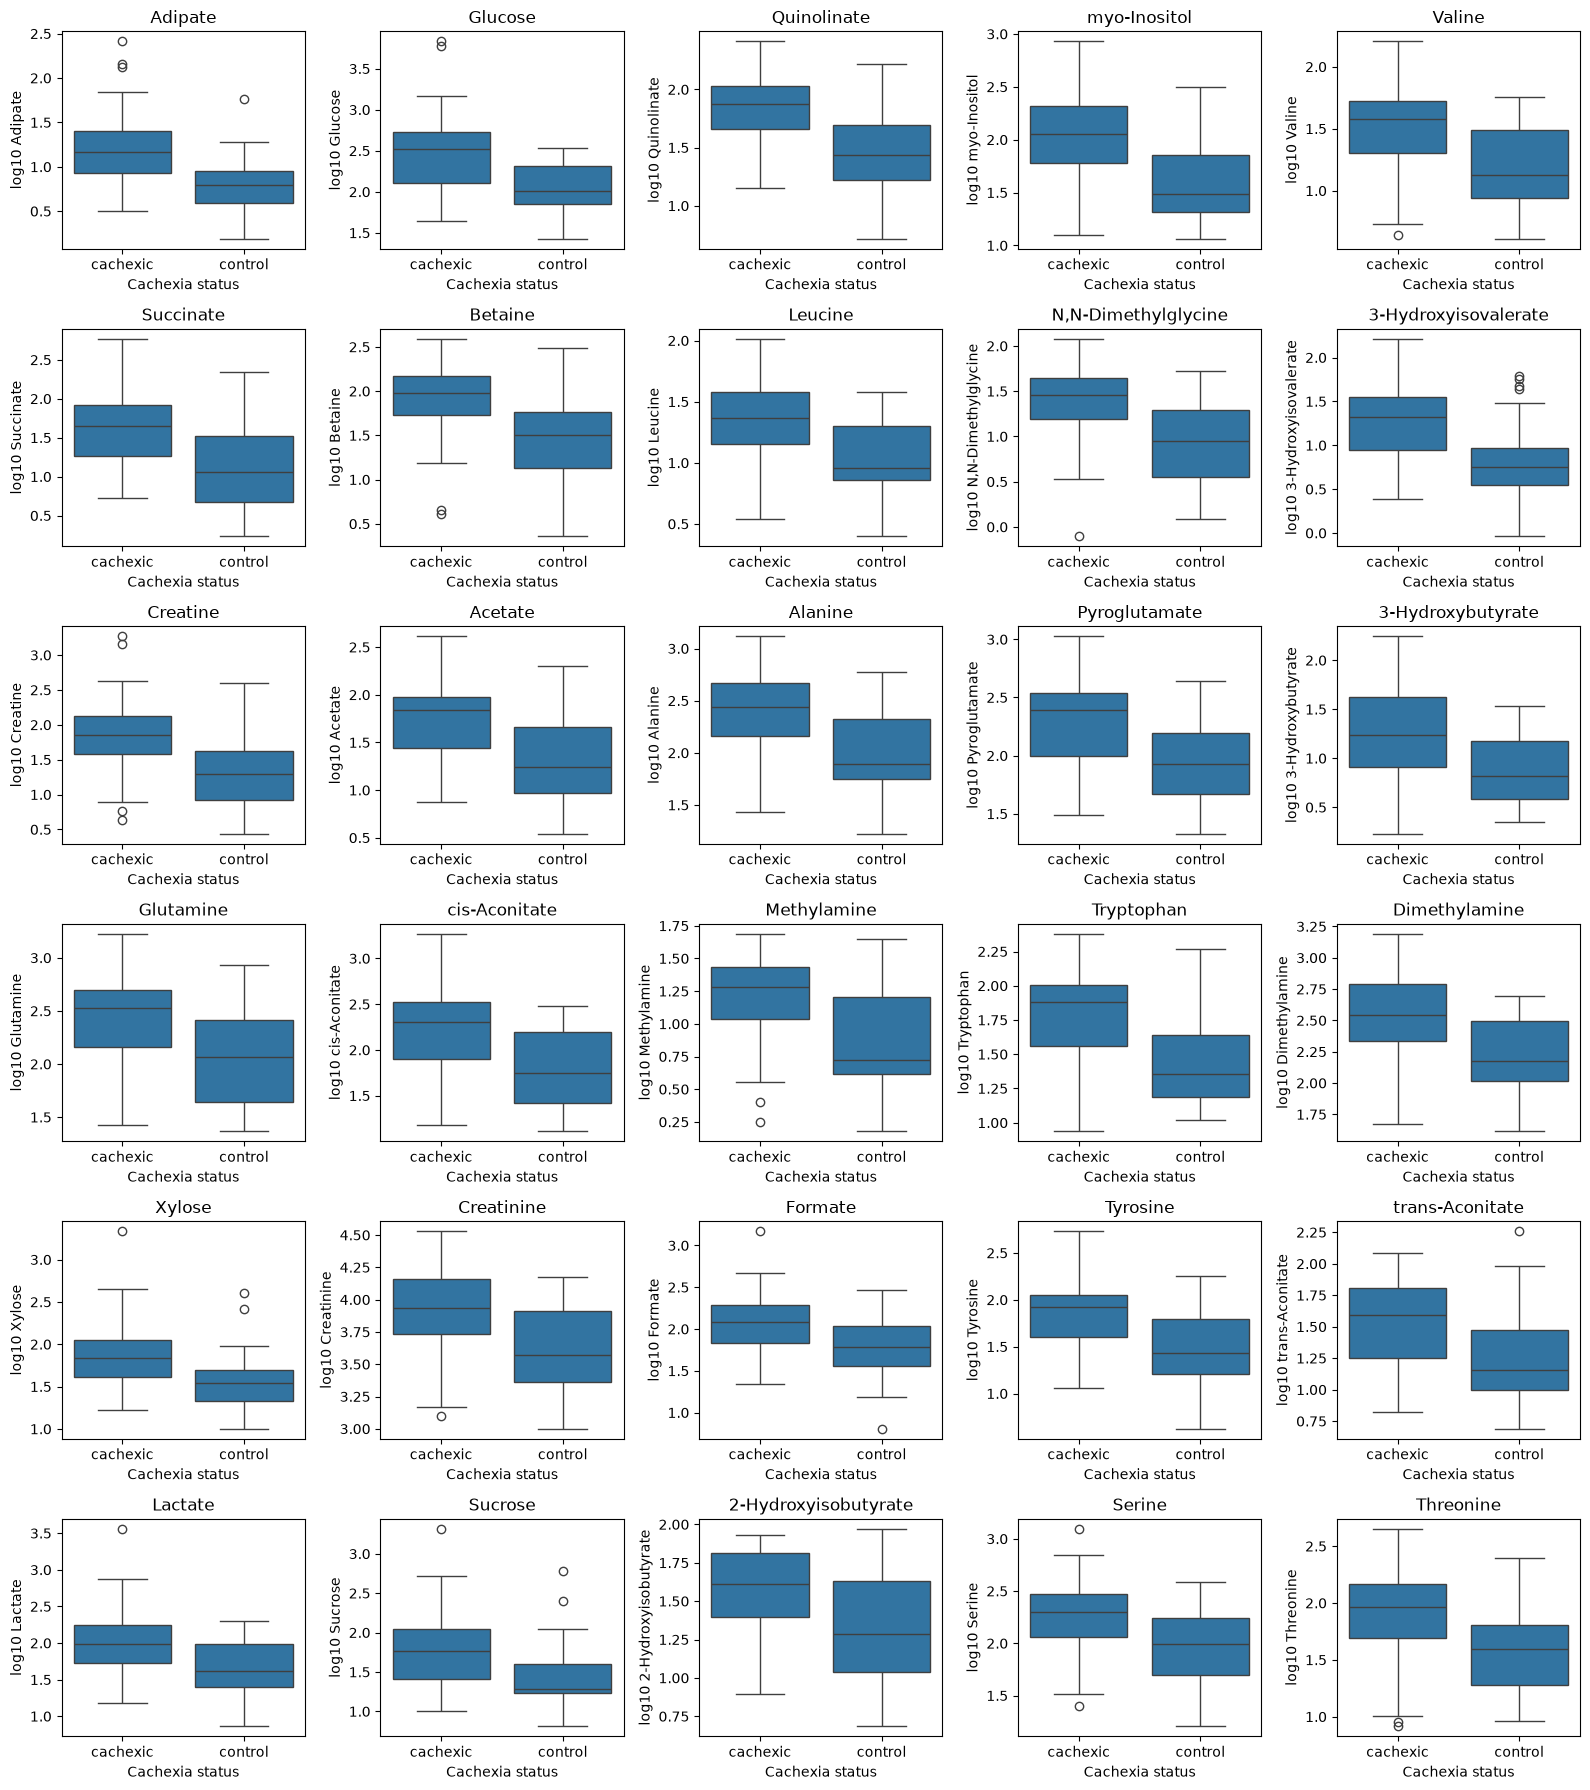

In [8]:
# Distribution visualisation

fig, axes = plt.subplots(6, 5, figsize = (16, 18))
axes = axes.flatten() # Convert axes to 1D array for easy iteration

for i, met in enumerate(top30_metabolites):
    axis = axes[i]
    sns.boxplot(data = df_log10, x = 'Label', y = met, ax = axis)
    axis.set_title(met)
    axis.set_xlabel('Cachexia status')
    axis.set_ylabel(f'log10 {met}')

plt.tight_layout()
plt.show()

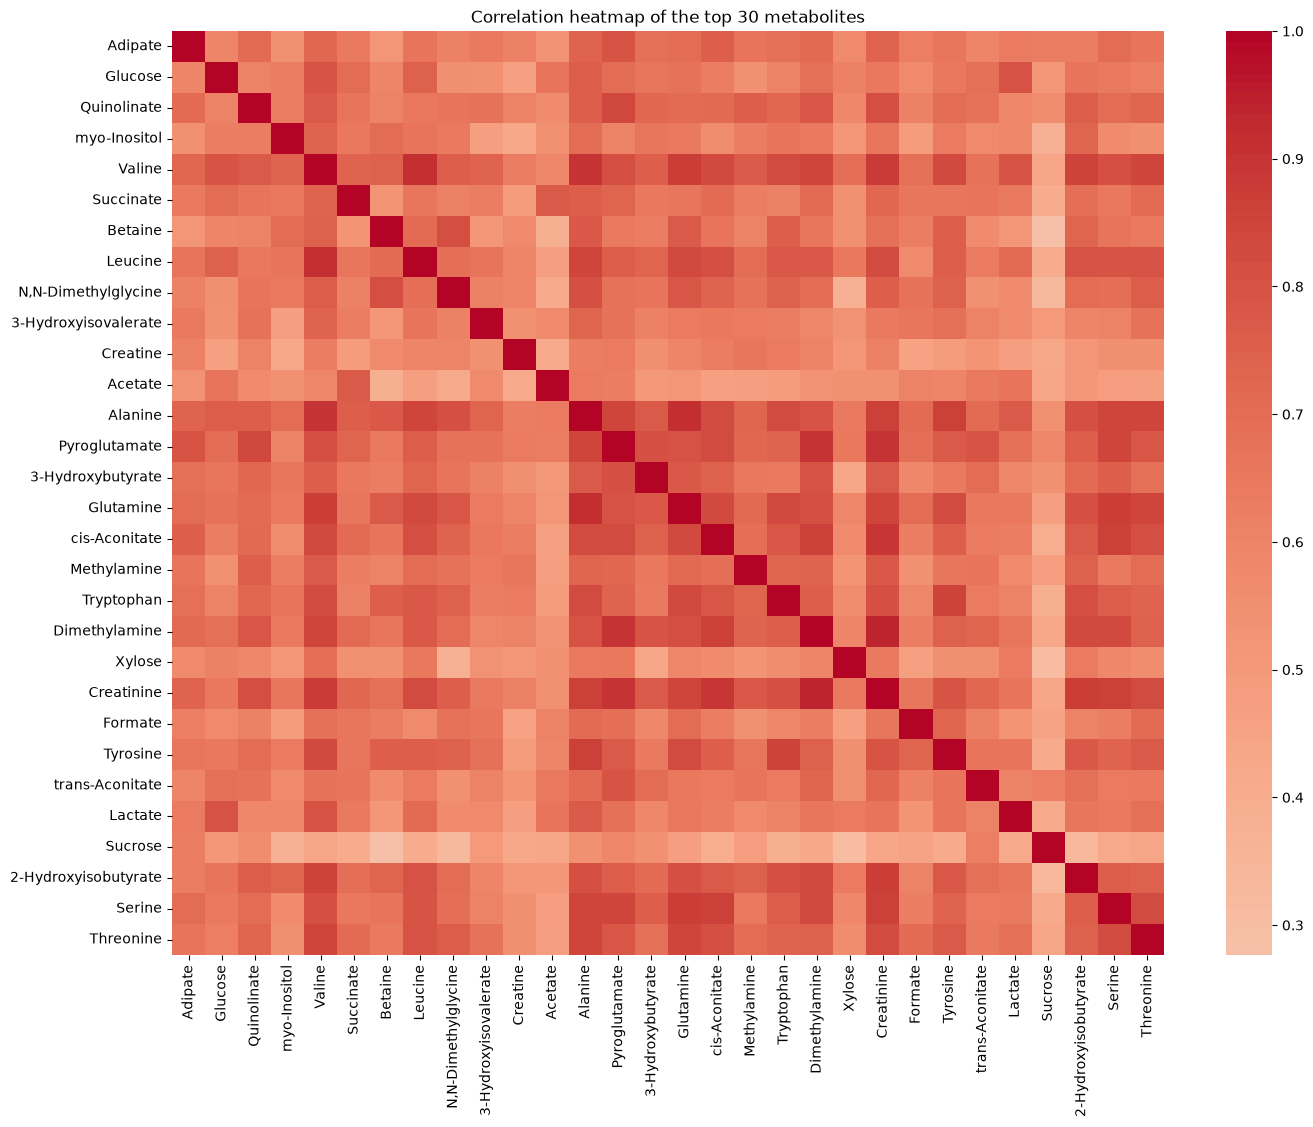

In [9]:
# Correlation heatmap

plt.figure(figsize = (16, 12))
sns.heatmap(df_log10[top30_metabolites].corr(), cmap = 'coolwarm', center = 0)
plt.title('Correlation heatmap of the top 30 metabolites')
plt.show()

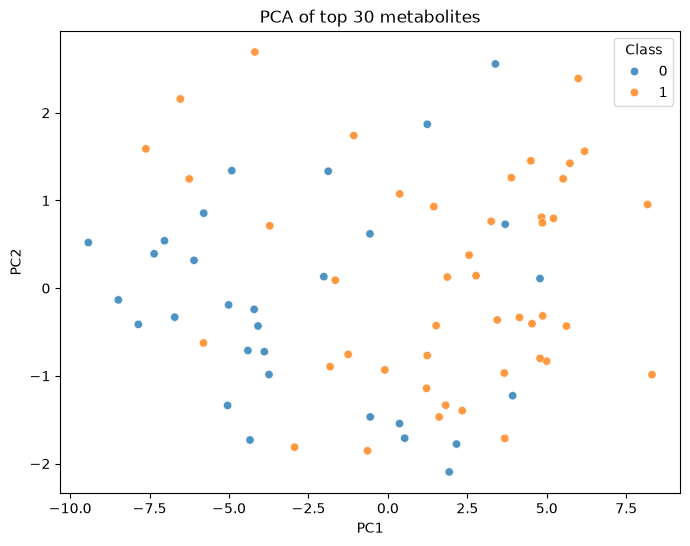

In [10]:
# Principal component analysis
# Imputation can be safely skipped as there are no missing values; added for robustness and reusability


x = df_log10[top30_metabolites] # Log10 data used to provide data with more even variance
y = df_log10['Class']

pca_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components = 2))
])

pca_df = pd.DataFrame(pca_pipeline.fit_transform(x), columns = ['PC1', 'PC2'])
pca_df['Class'] = y.values

plt.figure(figsize = (8, 6))
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', hue = 'Class', alpha = 0.8)
plt.title('PCA of top 30 metabolites')
plt.show()

## Model comparison (stratified 5-fold cross-validation)

Five classifiers, each in a scikit-learn pipeline (median imputation + standard scaling), compared by mean ROC-AUC on the training set.

In [11]:
# Split data into stratified (equal proportions) training and test set (70/30).
# All k-fold validation will be performed on training set.
x_train, x_test, y_train, y_test = train_test_split(
    df_log10[top30_metabolites], df_log10['Class'], test_size = 0.30, stratify = y, random_state = 15
)

print(y_train.value_counts(normalize = True), y_test.value_counts(normalize = True))

Class
1    0.596154
0    0.403846
Name: proportion, dtype: float64 Class
1    0.608696
0    0.391304
Name: proportion, dtype: float64


In [12]:
# Perform 5-fold cross-validation. roc_auc_score is used here for simplicity
# Full ROC and AUC are saved for the final model

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 15)

models = {
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter = 500))
    ]),
    'SVM': Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler()),
        ('model', SVC(probability = True)) # Enables probability estimates for downstream
    ]),
    'KNN': Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors = 5))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state = 15))
    ]),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(random_state = 15))
    ])
}

# Retrieve AUC for each model
cv_results = {}
for name, output in models.items():
    scores = cross_val_score(output, x_train, y_train, cv = cv, scoring = 'roc_auc')
    cv_results[name] = (scores.mean(), scores.std())

# Sort the models by AUC, then by lowest SD. lambda = small, one-time use function
cv_results_ordered = sorted(cv_results.items(), key = lambda x: (-x[1][0], x[1][1]))
for name, (mean_auc, std_auc) in cv_results_ordered:
    print(f'{name}: AUC = {mean_auc:.2f} +/- {std_auc:.2f}')
print('Best model:', cv_results_ordered[0][0], '\n')

/home/edenp/miniforge3/envs/cachexia-ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/edenp/miniforge3/envs/cachexia-ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/edenp/miniforge3/envs/cachexia-ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/edenp/miniforge3/envs/cachexia-ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: Fu

SVM: AUC = 0.77 +/- 0.15
GradientBoosting: AUC = 0.76 +/- 0.14
RandomForest: AUC = 0.75 +/- 0.17
LogisticRegression: AUC = 0.71 +/- 0.21
KNN: AUC = 0.68 +/- 0.22
Best model: SVM 



## Final model and evaluation

Refit the best model on the full training set and evaluate on the held-out test set (classification report, ROC curve, AUC).

In [13]:
 # Train best model on the entire test set
best_model_name = cv_results_ordered[0][0]
best_model = models[best_model_name]
best_model.fit(x_train, y_train)

y_prediction = best_model.predict(x_test)

print('Test accuracy:', accuracy_score(y_test, y_prediction))
print(classification_report(y_test, y_prediction, digits = 3))

Test accuracy: 0.7391304347826086
              precision    recall  f1-score   support

           0      0.714     0.556     0.625         9
           1      0.750     0.857     0.800        14

    accuracy                          0.739        23
   macro avg      0.732     0.706     0.713        23
weighted avg      0.736     0.739     0.732        23



/home/edenp/miniforge3/envs/cachexia-ml/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


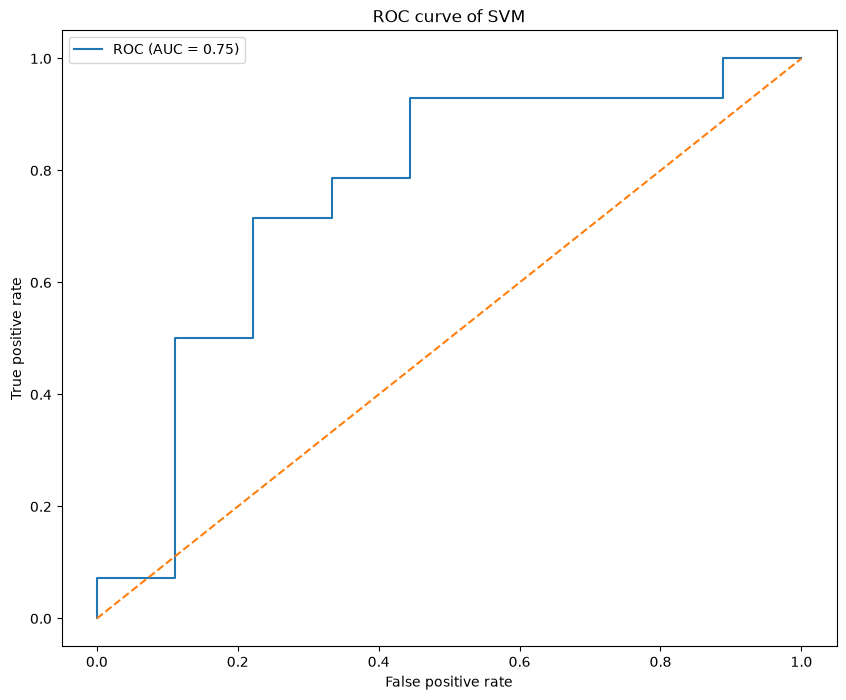

In [14]:
y_probability = best_model.predict_proba(x_test)[:, 1] # returns cachexic probability (column 1 of all rows) for each sample in x_test
false_pos, true_pos, thresholds = roc_curve(y_test, y_probability) # Return false & true positive rate at each threshold computed by the roc_curve function
test_auc = auc(false_pos, true_pos) # Determine AUC from the false & true positive rates at each threshold

plt.figure(figsize = (10, 8))
plt.plot(false_pos, true_pos, label = f'ROC (AUC = {test_auc:.2f})') # Plot ROC curve with label stating AUC value
plt.plot([0, 1], [0, 1], linestyle = '--') # Plot a diagonal line to represent 0.5 AUC
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title(f'ROC curve of {best_model_name}')
plt.legend()
plt.show()